In [ ]:
import os
import cv2
import numpy as np
import random
from pathlib import Path
import matplotlib.pyplot as plt

In [ ]:
import zipfile
import os

zip_path = "/content/images.zip"
extract_path = "datasets/gemstone_restore/train/B"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [ ]:
zip_path = "/content/images.zip"
extract_dir = "datasets/gemstone_restore/train/B"
masked_dir = "datasets/gemstone_restore/train/A_combined"
os.makedirs(extract_dir, exist_ok=True)
os.makedirs(masked_dir, exist_ok=True)

In [ ]:
import os
import cv2
import numpy as np
import random
from pathlib import Path
import matplotlib.pyplot as plt

extract_dir = "datasets/gemstone_restore/train/B/images"
masked_dir = "datasets/gemstone_restore/train/A_combined"
os.makedirs(masked_dir, exist_ok=True)

image_files = list(Path(extract_dir).rglob("*"))
image_files = [f for f in image_files if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]

print(f"[INFO] Found {len(image_files)} images for masking...")

def random_block_mask(img, blocks=5):
    h, w, _ = img.shape
    mask = np.ones_like(img, dtype=np.uint8) * 255
    for _ in range(blocks):
        x, y = np.random.randint(0, w - 40), np.random.randint(0, h - 40)
        bw, bh = np.random.randint(20, 50), np.random.randint(20, 50)
        mask[y:y + bh, x:x + bw] = 0
    return cv2.bitwise_and(img, mask), mask

def hsv_threshold_mask(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lower = np.array([0, 0, 0])
    upper = np.array([180, 255, 50])
    mask = cv2.inRange(hsv, lower, upper)
    mask_bgr = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
    return cv2.bitwise_and(img, 255 - mask_bgr), 255 - mask_bgr

def free_form_mask(img, strokes=8):
    h, w, _ = img.shape
    mask = np.ones_like(img, dtype=np.uint8) * 255
    for _ in range(strokes):
        x1, y1 = np.random.randint(w), np.random.randint(h)
        x2, y2 = np.random.randint(w), np.random.randint(h)
        thickness = np.random.randint(5, 20)
        cv2.line(mask, (x1, y1), (x2, y2), (0, 0, 0), thickness)
    return cv2.bitwise_and(img, mask), mask

strategies = [random_block_mask, hsv_threshold_mask, free_form_mask]

for img_path in image_files:
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    strategy = random.choice(strategies)
    masked_img, _ = strategy(img.copy())
    cv2.imwrite(os.path.join(masked_dir, img_path.name), masked_img)

print(f"[INFO] Masked images saved to: {masked_dir}")

[INFO] Found 35 images for masking...
[INFO] Masked images saved to: datasets/gemstone_restore/train/A_combined


[INFO] Masked images saved to: datasets/gemstone_restore/train/A_combined


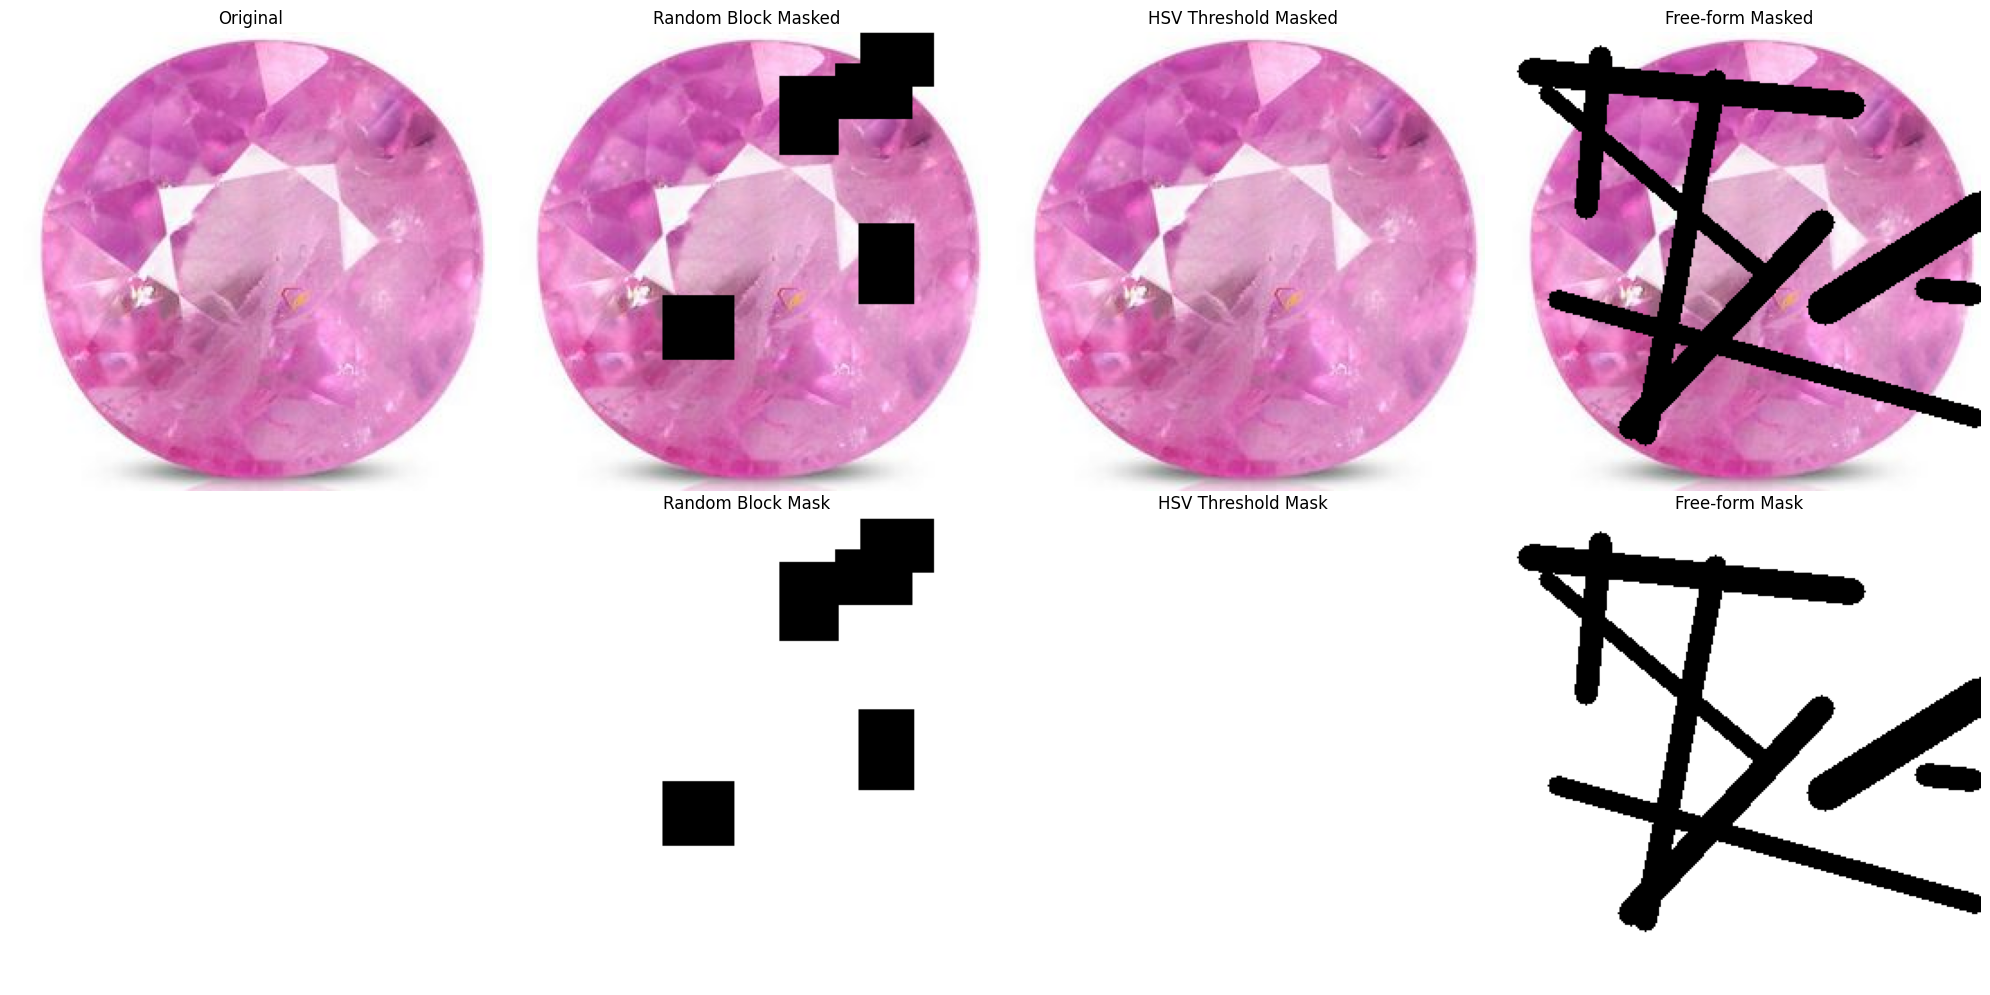

In [ ]:
for img_path in image_files:
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    strategy = random.choice(strategies)
    masked_img, _ = strategy(img.copy())
    cv2.imwrite(os.path.join(masked_dir, img_path.name), masked_img)

print(f"[INFO] Masked images saved to: {masked_dir}")

sample_img = cv2.imread(str(image_files[0]))
sample_rgb = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes[0, 0].imshow(sample_rgb)
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

for idx, (name, func) in enumerate(zip(['Random Block', 'HSV Threshold', 'Free-form'],
                                       [random_block_mask, hsv_threshold_mask, free_form_mask])):
    masked, mask = func(sample_img.copy())
    masked_rgb = cv2.cvtColor(masked, cv2.COLOR_BGR2RGB)
    mask_rgb = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

    axes[0, idx + 1].imshow(masked_rgb)
    axes[0, idx + 1].set_title(f"{name} Masked")
    axes[0, idx + 1].axis("off")

    axes[1, idx + 1].imshow(mask_rgb)
    axes[1, idx + 1].set_title(f"{name} Mask")
    axes[1, idx + 1].axis("off")

axes[1, 0].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
import os
from PIL import Image
from torch.utils.data import Dataset
import torchvision.transforms as transforms

class GemstoneInpaintingDataset(Dataset):
    def __init__(self, a_dir, b_dir, image_size=256):
        self.a_dir = a_dir
        self.b_dir = b_dir
        self.image_filenames = sorted([
            f for f in os.listdir(a_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])

        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        a_path = os.path.join(self.a_dir, self.image_filenames[idx])
        b_path = os.path.join(self.b_dir, self.image_filenames[idx])

        a_img = Image.open(a_path).convert("RGB")
        b_img = Image.open(b_path).convert("RGB")

        a_tensor = self.transform(a_img)
        b_tensor = self.transform(b_img)

        return {"A": a_tensor, "B": b_tensor}

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SelfAttention(nn.Module):
    def __init__(self, in_dim):
        super(SelfAttention, self).__init__()
        self.query_conv = nn.Conv2d(in_dim, in_dim // 8, 1)
        self.key_conv   = nn.Conv2d(in_dim, in_dim // 8, 1)
        self.value_conv = nn.Conv2d(in_dim, in_dim, 1)
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        B, C, H, W = x.size()

        proj_query = self.query_conv(x).view(B, -1, W * H).permute(0, 2, 1)  # B x N x C'
        proj_key   = self.key_conv(x).view(B, -1, W * H)                     # B x C' x N
        energy     = torch.bmm(proj_query, proj_key)                         # B x N x N
        attention  = F.softmax(energy, dim=-1)

        proj_value = self.value_conv(x).view(B, -1, W * H)                   # B x C x N
        out = torch.bmm(proj_value, attention.permute(0, 2, 1))              # B x C x N
        out = out.view(B, C, H, W)

        out = self.gamma * out + x
        return out


In [ ]:
import torch
import torch.nn as nn

class UNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, down=True, use_attention=False):
        super().__init__()
        self.use_attention = use_attention
        if down:
            self.block = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 4, 2, 1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.LeakyReLU(0.2)
            )
        else:
            self.block = nn.Sequential(
                nn.ConvTranspose2d(in_channels, out_channels, 4, 2, 1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU()
            )
        self.attn = SelfAttention(out_channels) if use_attention else nn.Identity()

    def forward(self, x):
        x = self.block(x)
        return self.attn(x)

class Generator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        super().__init__()

        self.down1 = UNetBlock(in_channels, 64, down=True)
        self.down2 = UNetBlock(64, 128, down=True)
        self.down3 = UNetBlock(128, 256, down=True, use_attention=True)
        self.down4 = UNetBlock(256, 512, down=True)

        self.up1 = UNetBlock(512, 256, down=False)
        self.up2 = UNetBlock(512, 128, down=False, use_attention=True)
        self.up3 = UNetBlock(256, 64, down=False)
        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, out_channels, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)

        u1 = self.up1(d4)
        u2 = self.up2(torch.cat([u1, d3], dim=1))
        u3 = self.up3(torch.cat([u2, d2], dim=1))
        return self.final(torch.cat([u3, d1], dim=1))


class Discriminator(nn.Module):
    def __init__(self, in_channels=6):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            SelfAttention(128),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 1, 4, 1, 1)
        )

    def forward(self, x, y):
        inp = torch.cat([x, y], dim=1)
        return self.model(inp)


In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.utils import save_image
from tqdm import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 8
IMAGE_SIZE = 256
LR = 2e-4
EPOCHS = 100
LAMBDA_L1 = 100

DATA_A = "datasets/gemstone_restore/train/A_combined"
DATA_B = "datasets/gemstone_restore/train/B/images"
SAVE_DIR = "checkpoints"
SAMPLE_DIR = "samples"

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(SAMPLE_DIR, exist_ok=True)

dataset = GemstoneInpaintingDataset(DATA_A, DATA_B, image_size=IMAGE_SIZE)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

gen = Generator().to(DEVICE)
disc = Discriminator().to(DEVICE)

opt_gen = torch.optim.Adam(gen.parameters(), lr=LR, betas=(0.5, 0.999))
opt_disc = torch.optim.Adam(disc.parameters(), lr=LR, betas=(0.5, 0.999))

criterion_GAN = nn.MSELoss()
criterion_L1 = nn.L1Loss()

print(f" Starting training for {EPOCHS} epochs...")
for epoch in range(EPOCHS):
    loop = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for i, batch in enumerate(loop):
        real_A = batch["A"].to(DEVICE)
        real_B = batch["B"].to(DEVICE)

        fake_B = gen(real_A)
        disc_real = disc(real_A, real_B)
        disc_fake = disc(real_A, fake_B.detach())
        loss_disc = 0.5 * (criterion_GAN(disc_real, torch.ones_like(disc_real)) +
                           criterion_GAN(disc_fake, torch.zeros_like(disc_fake)))

        opt_disc.zero_grad()
        loss_disc.backward()
        opt_disc.step()

        disc_fake = disc(real_A, fake_B)
        loss_gan = criterion_GAN(disc_fake, torch.ones_like(disc_fake))
        loss_l1 = criterion_L1(fake_B, real_B)
        loss_gen = loss_gan + LAMBDA_L1 * loss_l1

        opt_gen.zero_grad()
        loss_gen.backward()
        opt_gen.step()

        loop.set_postfix({
            "D Loss": loss_disc.item(),
            "G Loss": loss_gen.item(),
            "L1": loss_l1.item()
        })

    if (epoch + 1) % 5 == 0:
        gen.eval()
        with torch.no_grad():
            samples = torch.cat([real_A[:4], fake_B[:4], real_B[:4]], dim=0)
            save_image(samples, os.path.join(SAMPLE_DIR, f"epoch_{epoch+1}.png"), nrow=4, normalize=True)
        gen.train()

    torch.save(gen.state_dict(), os.path.join(SAVE_DIR, f"gen_epoch{epoch+1}.pth"))
    torch.save(disc.state_dict(), os.path.join(SAVE_DIR, f"disc_epoch{epoch+1}.pth"))

print(" Training complete.")

[INFO] Starting training for 100 epochs...


Epoch 100/100: 100%|██████████| 5/5 [03:47<00:00, 45.54s/it, D Loss=0.0525, G Loss=6.42, L1=0.055]


[INFO] Training complete.


In [ ]:
import os
import torch
from PIL import Image
from torchvision import transforms
from torchvision.utils import save_image

INPUT_DIR = "/content/datasets/gemstone_restore/train/B/images"
OUTPUT_DIR = "restored_images"
CHECKPOINT = "/content/gen_epoch92.pth"
IMAGE_SIZE = 256

os.makedirs(OUTPUT_DIR, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

gen = Generator().to(DEVICE)
gen.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
gen.eval()

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

image_files = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

print(f"[INFO] Restoring {len(image_files)} images...")

for fname in image_files:
    path = os.path.join(INPUT_DIR, fname)
    image = Image.open(path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        restored = gen(input_tensor)

    save_path = os.path.join(OUTPUT_DIR, fname)
    save_image(restored, save_path, normalize=True)

print(f"Restored images saved to: {OUTPUT_DIR}")

[INFO] Restoring 35 images...
[DONE] Restored images saved to: restored_images


In [ ]:
!git clone https://github.com/xinntao/Real-ESRGAN.git
%cd Real-ESRGAN
!pip install -r requirements.txt
!python setup.py develop
!wget https://github.com/xinntao/Real-ESRGAN/releases/download/v0.2.5/RealESRGAN_x4plus.pth -P weights


Cloning into 'Real-ESRGAN'...
remote: Enumerating objects: 759, done.
remote: Counting objects: 100% (121/121), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 759 (delta 106), reused 98 (delta 98), pack-reused 638 (from 1)
Receiving objects: 100% (759/759), 5.38 MiB | 14.30 MiB/s, done.
Resolving deltas: 100% (415/415), done.
/content/Real-ESRGAN
/usr/local/lib/python3.11/dist-packages/setuptools/__init__.py:94: _DeprecatedInstaller: setuptools.installer and fetch_build_eggs are deprecated.
!!

        ********************************************************************************
        Requirements should be satisfied by a PEP 517 installer.
        If you are using pip, you can try `pip install --use-pep517`.
        ********************************************************************************

!!
  dist.fetch_build_eggs(dist.setup_requires)
running develop
/usr/local/lib/python3.11/dist-packages/setuptools/command/develop.py:41: EasyInstallDeprecationWarn

In [ ]:
!pip install torchvision==0.15.2 --upgrade --force-reinstall

  Using cached numpy-2.3.1-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached wheel-0.45.1-py3-none-any.whl.metadata (2.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 619.9/619.9 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.1/317.1 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.0/21.0 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.1/557.1 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.6/102.6 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.2/173.2 MB 6

In [ ]:
!pip install -r /content/Real-ESRGAN/requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.5/19.5 MB 44.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.1
    Uninstalling numpy-2.3.1:
      Successfully uninstalled numpy-2.3.1


In [ ]:
%cd /content/Real-ESRGAN
!python inference_realesrgan.py -n RealESRGAN_x4plus -i /content/restored_images -o /content/enhanced_outputs --fp32

/content/Real-ESRGAN
/usr/local/lib/python3.11/dist-packages/torchvision/transforms/functional_tensor.py:5: UserWarning: The torchvision.transforms.functional_tensor module is deprecated in 0.15 and will be **removed in 0.17**. Please don't rely on it. You probably just need to use APIs in torchvision.transforms.functional or in torchvision.transforms.v2.functional.
  warnings.warn(
Testing 0 Amethyst - 6.13 Carats
Testing 1 Amethyst - 7.7 carats 1
Testing 2 Amethyst - 7.7 carats
Testing 3 Ametrine - 31.42 Carats 2
Testing 4 Ametrine - 31.42 Carats
Testing 5 Emerald - 2.33 carats
Testing 6 Emerald - 3.02 carats
Testing 7 Hessonite Garnet - 2.58 carats
Testing 8 Hessonite Garnet - 2.72 carats
Testing 9 Moissanite - 1.26 carats
Testing 10 Moissanite - 1.32 carats
Testing 11 Morgonite - 10.87 carats
Testing 12 Morgonite - 12.32 carats
Testing 13 Peridot - 3.1 carats
Testing 14 Peridot - 4.71 carats
Testing 15 Pink Sapphire 6.46 carats
Testing 16 Pink Sapphire 7.32 carats
Testing 17 Real B

In [ ]:
!zip -r enhanced_outputs.zip /content/enhanced_outputs
from google.colab import files
files.download("enhanced_outputs.zip")

  adding: content/enhanced_outputs/ (stored 0%)
  adding: content/enhanced_outputs/Hessonite Garnet - 2.72 carats_out.JPG (deflated 1%)
  adding: content/enhanced_outputs/amber carats 7.55_out.JPG (deflated 2%)
  adding: content/enhanced_outputs/Emerald - 3.02 carats_out.JPG (deflated 1%)
  adding: content/enhanced_outputs/Moissanite - 1.32 carats_out.JPG (deflated 0%)
  adding: content/enhanced_outputs/Emerald - 2.33 carats_out.JPG (deflated 2%)
  adding: content/enhanced_outputs/Yellow Beryl - 10.15 carats_out.JPG (deflated 3%)
  adding: content/enhanced_outputs/Rubellite - 4.27 carats_out.JPG (deflated 2%)
  adding: content/enhanced_outputs/Yellow Topaz - 6.82 carats_out.JPG (deflated 2%)
  adding: content/enhanced_outputs/amber carats 6.05_out.JPG (deflated 1%)
  adding: content/enhanced_outputs/Pink Sapphire 6.46 carats_out.JPG (deflated 1%)
  adding: content/enhanced_outputs/Peridot - 3.1 carats_out.JPG (deflated 1%)
  adding: content/enhanced_outputs/Morgonite - 10.87 carats_out

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Dual Attention**

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, Input, callbacks
import matplotlib.pyplot as plt
from glob import glob
from PIL import Image

In [ ]:
class ChannelAttention(layers.Layer):
    def __init__(self, reduction=8):
        super(ChannelAttention, self).__init__()
        self.reduction = reduction

    def build(self, input_shape):
        self.avg_pool = layers.GlobalAveragePooling2D()
        self.max_pool = layers.GlobalMaxPooling2D()
        self.fc1 = layers.Dense(input_shape[-1] // self.reduction, activation='relu')
        self.fc2 = layers.Dense(input_shape[-1])

    def call(self, x):
        avg_out = self.fc2(self.fc1(self.avg_pool(x)))
        max_out = self.fc2(self.fc1(self.max_pool(x)))
        out = tf.nn.sigmoid(avg_out + max_out)
        return x * tf.expand_dims(tf.expand_dims(out, 1), 1)

class SpatialAttention(layers.Layer):
    def __init__(self):
        super(SpatialAttention, self).__init__()
        self.conv = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')

    def call(self, x, return_attention=False):
        avg_pool = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(x, axis=-1, keepdims=True)
        concat = tf.concat([avg_pool, max_pool], axis=-1)
        attention = self.conv(concat)
        if return_attention:
            return attention
        return x * attention

class DualAttention(layers.Layer):
    def __init__(self):
        super(DualAttention, self).__init__()
        self.ca = ChannelAttention()
        self.sa = SpatialAttention()

    def call(self, x):
        x = self.ca(x)
        x = self.sa(x)
        return x

In [ ]:
def res_block(x, filters):
    shortcut = x
    x = layers.Conv2D(filters, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    return layers.Add()([x, shortcut])

def build_generator(input_shape=(256, 256, 3)):
    inputs = Input(shape=input_shape)
    x = layers.Conv2D(64, kernel_size=7, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(128, kernel_size=3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(256, kernel_size=3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    for _ in range(6):
        x = res_block(x, 256)

    x = DualAttention()(x)

    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(128, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(64, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(3, kernel_size=7, padding='same', activation='tanh')(x)
    return Model(inputs, x, name='DualAttentionGenerator')


In [ ]:
def load_images(path, size=(256, 256)):
    image_paths = sorted(glob(os.path.join(path, '*.JPG')))
    images = []
    for p in image_paths:
        img = Image.open(p).convert('RGB').resize(size)
        images.append(np.array(img) / 127.5 - 1.0)
    return np.array(images)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras.models import Model

def visualize_dual_attention(model, image_path, save_path=None):
    """
    Visualize dual attention maps for your specific DualAttention architecture
    """
    img = Image.open(image_path).convert('RGB').resize((256, 256))
    img_tensor = tf.expand_dims((np.array(img) / 127.5 - 1.0), 0)

    dual_attention_layer = None
    dual_attention_layer_index = None

    for i, layer in enumerate(model.layers):
        if isinstance(layer, DualAttention) or 'dual_attention' in layer.name.lower():
            dual_attention_layer = layer
            dual_attention_layer_index = i
            break

    if dual_attention_layer is None:
        print("DualAttention layer not found!")
        return

    feature_extractor = Model(inputs=model.input,
                            outputs=model.layers[dual_attention_layer_index-1].output)
    features = feature_extractor(img_tensor)

    channel_attention_output = dual_attention_layer.ca(features)

    spatial_attention_map = dual_attention_layer.sa(channel_attention_output, return_attention=True)

    spatial_map = spatial_attention_map[0, :, :, 0].numpy()

    channel_weights = dual_attention_layer.ca.fc2(
        dual_attention_layer.ca.fc1(dual_attention_layer.ca.avg_pool(features))
    )[0].numpy()

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    axes[0, 0].imshow(img)
    axes[0, 0].set_title("Original Image")
    axes[0, 0].axis('off')

    im1 = axes[0, 1].imshow(spatial_map, cmap='viridis')
    axes[0, 1].set_title("Spatial Attention Map")
    axes[0, 1].axis('off')
    plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

    axes[1, 0].bar(range(len(channel_weights)), channel_weights)
    axes[1, 0].set_title("Channel Attention Weights")
    axes[1, 0].set_xlabel("Channel Index")
    axes[1, 0].set_ylabel("Attention Weight")

    axes[1, 1].imshow(img)
    axes[1, 1].imshow(spatial_map, cmap='hot', alpha=0.6)
    axes[1, 1].set_title("Spatial Attention Overlay")
    axes[1, 1].axis('off')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    else:
        plt.show()
    plt.close()

def visualize_attention_detailed(model, image_path, save_path=None):
    """
    More detailed visualization showing intermediate steps
    """
    img = Image.open(image_path).convert('RGB').resize((256, 256))
    img_tensor = tf.expand_dims((np.array(img) / 127.5 - 1.0), 0)

    dual_attention_layer = None
    dual_attention_layer_index = None

    for i, layer in enumerate(model.layers):
        if isinstance(layer, DualAttention) or 'dual_attention' in layer.name.lower():
            dual_attention_layer = layer
            dual_attention_layer_index = i
            break

    if dual_attention_layer is None:
        print("DualAttention layer not found!")
        return

    feature_extractor = Model(inputs=model.input,
                            outputs=model.layers[dual_attention_layer_index-1].output)
    original_features = feature_extractor(img_tensor)

    channel_attended_features = dual_attention_layer.ca(original_features)

    final_output = dual_attention_layer.sa(channel_attended_features)
    spatial_attention_map = dual_attention_layer.sa(channel_attended_features, return_attention=True)

    spatial_map = spatial_attention_map[0, :, :, 0].numpy()

    avg_pooled = dual_attention_layer.ca.avg_pool(original_features)
    max_pooled = dual_attention_layer.ca.max_pool(original_features)

    avg_weights = dual_attention_layer.ca.fc2(dual_attention_layer.ca.fc1(avg_pooled))[0].numpy()
    max_weights = dual_attention_layer.ca.fc2(dual_attention_layer.ca.fc1(max_pooled))[0].numpy()
    final_channel_weights = tf.nn.sigmoid(avg_weights + max_weights).numpy()

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    axes[0, 0].imshow(img)
    axes[0, 0].set_title("Original Image")
    axes[0, 0].axis('off')

    im1 = axes[0, 1].imshow(spatial_map, cmap='viridis')
    axes[0, 1].set_title("Spatial Attention Map")
    axes[0, 1].axis('off')
    plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

    axes[0, 2].imshow(img)
    axes[0, 2].imshow(spatial_map, cmap='hot', alpha=0.6)
    axes[0, 2].set_title("Spatial Attention Overlay")
    axes[0, 2].axis('off')

    axes[1, 0].bar(range(len(avg_weights)), avg_weights)
    axes[1, 0].set_title("Channel Attention (Avg Pool)")
    axes[1, 0].set_xlabel("Channel Index")
    axes[1, 0].set_ylabel("Weight")

    axes[1, 1].bar(range(len(max_weights)), max_weights)
    axes[1, 1].set_title("Channel Attention (Max Pool)")
    axes[1, 1].set_xlabel("Channel Index")
    axes[1, 1].set_ylabel("Weight")

    axes[1, 2].bar(range(len(final_channel_weights)), final_channel_weights)
    axes[1, 2].set_title("Final Channel Attention Weights")
    axes[1, 2].set_xlabel("Channel Index")
    axes[1, 2].set_ylabel("Attention Weight")

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    else:
        plt.show()
    plt.close()

def visualize_attention_simple(model, image_path, save_path=None):
    """
    Simplified version of your original function but fixed for dual attention
    """
    img = Image.open(image_path).convert('RGB').resize((256, 256))
    img_tensor = tf.expand_dims((np.array(img) / 127.5 - 1.0), 0)

    dual_attention_index = None
    for i, layer in enumerate(model.layers):
        if isinstance(layer, DualAttention):
            dual_attention_index = i
            break

    if dual_attention_index is None:
        print("DualAttention layer not found!")
        return

    feature_extractor = Model(inputs=model.input,
                            outputs=model.layers[dual_attention_index-1].output)
    features = feature_extractor(img_tensor)

    sa = SpatialAttention()
    ca = ChannelAttention()
    channel_attended = ca(features)
    att_map = sa(channel_attended, return_attention=True)
    att_map = att_map[0, :, :, 0].numpy()

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(img)
    ax[0].set_title("Original Image")
    ax[0].axis('off')

    ax[1].imshow(att_map, cmap='viridis')
    ax[1].set_title("Spatial Attention Map")
    ax[1].axis('off')

    if save_path:
        plt.savefig(save_path)
    else:
        plt.show()
    plt.close()

model = build_generator()

#visualize_dual_attention(model, "/content/datasets/gemstone_restore/train/B/images/Amethyst - 6.13 Carats.JPG", "dual_attention.png")
visualize_attention_detailed(model, "/content/datasets/gemstone_restore/train/B/images/Amethyst - 6.13 Carats.JPG", "detailed_attention.png")


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import os
from sklearn.model_selection import train_test_split

class GlareRemovalGAN:
    def __init__(self, img_height=256, img_width=256, channels=3):
        self.img_height = img_height
        self.img_width = img_width
        self.channels = channels
        self.img_shape = (self.img_height, self.img_width, self.channels)

        self.discriminator = self.build_discriminator()
        self.discriminator.compile(loss='binary_crossentropy',
                                 optimizer=keras.optimizers.Adam(0.0002, 0.5),
                                 metrics=['accuracy'])

        self.generator = self.build_generator()

        glared_img = layers.Input(shape=self.img_shape)
        clean_img = self.generator(glared_img)

        self.discriminator.trainable = False

        validity = self.discriminator(clean_img)

        self.combined = keras.Model(glared_img, [clean_img, validity])
        self.combined.compile(loss=['mse', 'binary_crossentropy'],
                            loss_weights=[100, 1],
                            optimizer=keras.optimizers.Adam(0.0002, 0.5))

    def build_generator(self):
        """U-Net based generator for glare removal"""

        def conv2d(layer_input, filters, f_size=4, bn=True):
            d = layers.Conv2D(filters, kernel_size=f_size, strides=2, padding='same')(layer_input)
            if bn:
                d = layers.BatchNormalization(momentum=0.8)(d)
            d = layers.LeakyReLU(alpha=0.2)(d)
            return d

        def deconv2d(layer_input, skip_input, filters, f_size=4, dropout_rate=0):
            u = layers.UpSampling2D(size=2)(layer_input)
            u = layers.Conv2D(filters, kernel_size=f_size, strides=1, padding='same', activation='relu')(u)
            if dropout_rate:
                u = layers.Dropout(dropout_rate)(u)
            u = layers.BatchNormalization(momentum=0.8)(u)
            u = layers.Concatenate()([u, skip_input])
            return u

        d0 = layers.Input(shape=self.img_shape)

        d1 = conv2d(d0, 64, bn=False)
        d2 = conv2d(d1, 128)
        d3 = conv2d(d2, 256)
        d4 = conv2d(d3, 512)
        d5 = conv2d(d4, 512)
        d6 = conv2d(d5, 512)
        d7 = conv2d(d6, 512)

        u1 = deconv2d(d7, d6, 512)
        u2 = deconv2d(u1, d5, 512)
        u3 = deconv2d(u2, d4, 512)
        u4 = deconv2d(u3, d3, 256)
        u5 = deconv2d(u4, d2, 128)
        u6 = deconv2d(u5, d1, 64)

        u7 = layers.UpSampling2D(size=2)(u6)
        output_img = layers.Conv2D(self.channels, kernel_size=4, strides=1, padding='same', activation='tanh')(u7)

        return keras.Model(d0, output_img)

    def build_discriminator(self):
        """PatchGAN discriminator"""

        def d_layer(layer_input, filters, f_size=4, bn=True):
            d = layers.Conv2D(filters, kernel_size=f_size, strides=2, padding='same')(layer_input)
            if bn:
                d = layers.BatchNormalization(momentum=0.8)(d)
            d = layers.LeakyReLU(alpha=0.2)(d)
            return d

        img = layers.Input(shape=self.img_shape)

        d1 = d_layer(img, 64, bn=False)
        d2 = d_layer(d1, 128)
        d3 = d_layer(d2, 256)
        d4 = d_layer(d3, 512)

        validity = layers.Conv2D(1, kernel_size=4, strides=1, padding='same')(d4)

        return keras.Model(img, validity)

    def preprocess_image(self, image_path):
        """Preprocess image for training"""
        img = cv2.imread(image_path)
        if img is None:
            return None

        img = cv2.resize(img, (self.img_width, self.img_height))

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = (img.astype(np.float32) - 127.5) / 127.5

        return img

    def create_synthetic_glare(self, clean_image):
        """Create synthetic glare and reflections on clean images"""
        h, w = clean_image.shape[:2]

        glare_mask = np.zeros((h, w), dtype=np.float32)

        num_glares = np.random.randint(1, 4)
        for _ in range(num_glares):
            center_x = np.random.randint(w//4, 3*w//4)
            center_y = np.random.randint(h//4, 3*h//4)
            radius = np.random.randint(20, 60)

            y, x = np.ogrid[:h, :w]
            mask = (x - center_x)**2 + (y - center_y)**2 <= radius**2
            glare_mask[mask] = np.random.uniform(0.3, 0.8)

        num_reflections = np.random.randint(0, 3)
        for _ in range(num_reflections):
            start_x = np.random.randint(0, w)
            start_y = np.random.randint(0, h)
            end_x = np.random.randint(0, w)
            end_y = np.random.randint(0, h)

            cv2.line(glare_mask, (start_x, start_y), (end_x, end_y),
                    np.random.uniform(0.2, 0.6), thickness=np.random.randint(2, 8))

        glare_mask = cv2.GaussianBlur(glare_mask, (15, 15), 0)

        glare_mask = np.stack([glare_mask] * 3, axis=-1)

        glared_image = clean_image + glare_mask
        glared_image = np.clip(glared_image, -1, 1)

        return glared_image

    def load_and_prepare_data(self, image_folder, validation_split=0.2):
        """Load images and create synthetic glare data"""
        image_files = [f for f in os.listdir(image_folder)
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        clean_images = []
        glared_images = []

        print(f"Processing {len(image_files)} images...")

        for i, filename in enumerate(image_files):
            img_path = os.path.join(image_folder, filename)
            clean_img = self.preprocess_image(img_path)

            if clean_img is not None:
                for _ in range(3):
                    glared_img = self.create_synthetic_glare(clean_img)
                    clean_images.append(clean_img)
                    glared_images.append(glared_img)

            if (i + 1) % 10 == 0:
                print(f"Processed {i + 1}/{len(image_files)} images")

        clean_images = np.array(clean_images)
        glared_images = np.array(glared_images)

        X_train, X_val, y_train, y_val = train_test_split(
            glared_images, clean_images, test_size=validation_split, random_state=42
        )

        return X_train, X_val, y_train, y_val

    def train(self, X_train, y_train, X_val, y_val, epochs=100, batch_size=1, save_interval=10):
        """Train the GAN"""

        valid = np.ones((batch_size,) + self.discriminator.output_shape[1:])
        fake = np.zeros((batch_size,) + self.discriminator.output_shape[1:])

        history = {
            'g_loss': [],
            'd_loss': [],
            'val_g_loss': []
        }

        for epoch in range(epochs):
            idx = np.random.randint(0, X_train.shape[0], batch_size)
            glared_imgs = X_train[idx]
            clean_imgs = y_train[idx]

            fake_clean = self.generator.predict(glared_imgs)

            d_loss_real = self.discriminator.train_on_batch(clean_imgs, valid)
            d_loss_fake = self.discriminator.train_on_batch(fake_clean, fake)
            d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

            g_loss = self.combined.train_on_batch(glared_imgs, [clean_imgs, valid])

            if epoch % 10 == 0:
                val_idx = np.random.randint(0, X_val.shape[0], min(batch_size, X_val.shape[0]))
                val_glared = X_val[val_idx]
                val_clean = y_val[val_idx]
                val_g_loss = self.combined.evaluate(val_glared, [val_clean, valid], verbose=0)
                history['val_g_loss'].append(val_g_loss[0])

            history['g_loss'].append(g_loss[0])
            history['d_loss'].append(d_loss[0])

            if epoch % 10 == 0:
                print(f"Epoch {epoch}, D loss: {d_loss[0]:.4f}, G loss: {g_loss[0]:.4f}")

            if epoch % save_interval == 0:
                self.save_sample_images(X_val, y_val, epoch)

        return history

    def save_sample_images(self, X_val, y_val, epoch, num_samples=3):
        """Save sample images showing glare removal progress"""
        idx = np.random.randint(0, X_val.shape[0], num_samples)
        glared_imgs = X_val[idx]
        clean_imgs = y_val[idx]

        generated_imgs = self.generator.predict(glared_imgs)

        glared_imgs = 0.5 * glared_imgs + 0.5
        clean_imgs = 0.5 * clean_imgs + 0.5
        generated_imgs = 0.5 * generated_imgs + 0.5

        fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))

        for i in range(num_samples):
            axes[i, 0].imshow(glared_imgs[i])
            axes[i, 0].set_title('Glared Image')
            axes[i, 0].axis('off')

            axes[i, 1].imshow(generated_imgs[i])
            axes[i, 1].set_title('Generated Clean')
            axes[i, 1].axis('off')

            axes[i, 2].imshow(clean_imgs[i])
            axes[i, 2].set_title('Ground Truth')
            axes[i, 2].axis('off')

        plt.tight_layout()
        plt.savefig(f'glare_removal_epoch_{epoch}.png', dpi=300, bbox_inches='tight')
        plt.close()

    def remove_glare(self, image_path, output_path=None):
        """Remove glare from a single image"""
        img = self.preprocess_image(image_path)
        if img is None:
            raise ValueError(f"Could not load image: {image_path}")

        img_batch = np.expand_dims(img, axis=0)

        clean_img = self.generator.predict(img_batch)[0]

        clean_img = (clean_img + 1) * 127.5
        clean_img = np.clip(clean_img, 0, 255).astype(np.uint8)

        clean_img = cv2.cvtColor(clean_img, cv2.COLOR_RGB2BGR)

        if output_path:
            cv2.imwrite(output_path, clean_img)
            print(f"Glare-removed image saved to: {output_path}")

        return clean_img

    def save_model(self, filepath):
        """Save the trained generator model"""
        self.generator.save(filepath)
        print(f"Model saved to: {filepath}")

    def load_model(self, filepath):
        """Load a pre-trained generator model"""
        self.generator = keras.models.load_model(filepath)
        print(f"Model loaded from: {filepath}")

if __name__ == "__main__":
    gan = GlareRemovalGAN(img_height=256, img_width=256)

    image_folder = "/content/datasets/gemstone_restore/train/B/images"

    try:
        X_train, X_val, y_train, y_val = gan.load_and_prepare_data(image_folder)
        print(f"Training data: {X_train.shape}, Validation data: {X_val.shape}")

        history = gan.train(X_train, y_train, X_val, y_val, epochs=200, batch_size=2)

        gan.save_model("glare_removal_generator.h5")

        test_image = "/content/datasets/gemstone_restore/train/B/images/Amethyst - 7.7 carats.JPG"
        output_image = "glare_removed_gemstone.jpg"

        gan.remove_glare(test_image, output_image)

    except Exception as e:
        print("Please update the image folder path and ensure you have gemstone images.")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Processing 35 images...
Processed 10/35 images
Processed 20/35 images
Processed 30/35 images
Training data: (84, 256, 256, 3), Validation data: (21, 256, 256, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py:82: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0, D loss: 6.8511, G loss: 108.4153
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Epoch 10, D loss: 5.0034, G loss: 46.4361
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Epoch 20, D loss: 4.9668, G loss: 29.3639
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━

Model saved to: glare_removal_generator.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step
Glare-removed image saved to: glare_removed_gemstone.jpg


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from scipy import ndimage
import random

class GemstoneRestorationGAN:
    def __init__(self, img_height=256, img_width=256, channels=3):
        self.img_height = img_height
        self.img_width = img_width
        self.channels = channels
        self.img_shape = (self.img_height, self.img_width, self.channels)

        self.discriminator = self.build_discriminator()
        self.discriminator.compile(loss='binary_crossentropy',
                                 optimizer=keras.optimizers.Adam(0.0002, 0.5),
                                 metrics=['accuracy'])

        self.generator = self.build_generator()

        corrupted_img = layers.Input(shape=self.img_shape)
        mask = layers.Input(shape=(self.img_height, self.img_width, 1))

        restored_img = self.generator([corrupted_img, mask])

        self.discriminator.trainable = False
        validity = self.discriminator(restored_img)

        self.combined = keras.Model([corrupted_img, mask], [restored_img, validity])
        self.combined.compile(loss=['mse', 'binary_crossentropy'],
                            loss_weights=[100, 1],
                            optimizer=keras.optimizers.Adam(0.0002, 0.5))

    def build_generator(self):
        """Advanced U-Net generator with attention for inpainting"""

        def conv_block(x, filters, kernel_size=3, strides=1, padding='same'):
            x = layers.Conv2D(filters, kernel_size, strides, padding)(x)
            x = layers.BatchNormalization()(x)
            x = layers.LeakyReLU(alpha=0.2)(x)
            return x

        def attention_block(x, filters):
            """Attention mechanism for better inpainting"""
            theta = layers.Conv2D(filters//8, 1, padding='same')(x)
            phi = layers.Conv2D(filters//8, 1, padding='same')(x)
            g = layers.Conv2D(filters//2, 1, padding='same')(x)

            theta = layers.Reshape((-1, filters//8))(theta)
            phi = layers.Reshape((-1, filters//8))(phi)
            g = layers.Reshape((-1, filters//2))(g)

            attention = layers.Dot(axes=[2, 2])([theta, phi])
            attention = layers.Activation('softmax')(attention)

            out = layers.Dot(axes=[2, 1])([attention, g])
            out = layers.Reshape((x.shape[1], x.shape[2], filters//2))(out)

            gamma = layers.Conv2D(1, 1, padding='same', activation='sigmoid')(out)
            out = layers.Conv2D(filters, 1, padding='same')(out)

            return layers.Add()([x, layers.Multiply()([gamma, out])])

        def deconv_block(x, skip, filters, kernel_size=3):
            x = layers.UpSampling2D(2)(x)
            x = layers.Conv2D(filters, kernel_size, padding='same')(x)
            x = layers.BatchNormalization()(x)
            x = layers.LeakyReLU(alpha=0.2)(x)
            x = layers.Concatenate()([x, skip])
            return x

        corrupted_img = layers.Input(shape=self.img_shape)
        mask = layers.Input(shape=(self.img_height, self.img_width, 1))

        masked_img = layers.Multiply()([corrupted_img, mask])
        input_combined = layers.Concatenate()([corrupted_img, masked_img, mask])

        e1 = conv_block(input_combined, 64, strides=2)
        e2 = conv_block(e1, 128, strides=2)
        e3 = conv_block(e2, 256, strides=2)
        e4 = conv_block(e3, 512, strides=2)
        e5 = conv_block(e4, 512, strides=2)
        e6 = conv_block(e5, 512, strides=2)

        bottleneck = conv_block(e6, 512)
        bottleneck = attention_block(bottleneck, 512)

        d1 = deconv_block(bottleneck, e5, 512)
        d2 = deconv_block(d1, e4, 512)
        d3 = deconv_block(d2, e3, 256)
        d4 = deconv_block(d3, e2, 128)
        d5 = deconv_block(d4, e1, 64)

        d6 = layers.UpSampling2D(2)(d5)
        output = layers.Conv2D(self.channels, 3, padding='same', activation='tanh')(d6)

        return keras.Model([corrupted_img, mask], output)

    def build_discriminator(self):
        """PatchGAN discriminator with spectral normalization"""

        def d_layer(x, filters, kernel_size=4, strides=2, norm=True):
            x = layers.Conv2D(filters, kernel_size, strides, padding='same')(x)
            if norm:
                x = layers.BatchNormalization()(x)
            x = layers.LeakyReLU(alpha=0.2)(x)
            return x

        img = layers.Input(shape=self.img_shape)

        x = d_layer(img, 64, norm=False)
        x = d_layer(x, 128)
        x = d_layer(x, 256)
        x = d_layer(x, 512)

        validity = layers.Conv2D(1, 4, padding='same')(x)

        return keras.Model(img, validity)

    def create_gemstone_texture(self, base_color, size=(64, 64)):
        """Generate realistic gemstone texture"""
        h, w = size

        texture = np.random.normal(0, 0.1, (h, w, 3))

        for _ in range(5):
            center_x = np.random.randint(w//4, 3*w//4)
            center_y = np.random.randint(h//4, 3*h//4)
            angle = np.random.uniform(0, 2*np.pi)

            xx, yy = np.meshgrid(np.arange(w), np.arange(h))
            rotated_x = (xx - center_x) * np.cos(angle) - (yy - center_y) * np.sin(angle)
            rotated_y = (xx - center_x) * np.sin(angle) + (yy - center_y) * np.cos(angle)

            pattern = np.sin(rotated_x * 0.1) * np.cos(rotated_y * 0.1)
            pattern = np.expand_dims(pattern, axis=2)
            texture += pattern * 0.05

        texture = texture * 0.3 + base_color * 0.7

        sparkle_mask = np.random.random((h, w)) < 0.02
        sparkle_mask = ndimage.gaussian_filter(sparkle_mask.astype(float), sigma=0.5)
        sparkle_mask = np.expand_dims(sparkle_mask, axis=2)
        texture += sparkle_mask * 0.5

        return np.clip(texture, 0, 1)

    def detect_gemstone_region(self, image):
        """Detect the main gemstone region in the image"""
        hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

        lower_bound = np.array([0, 30, 30])
        upper_bound = np.array([180, 255, 200])

        gemstone_mask = cv2.inRange(hsv, lower_bound, upper_bound)

        contours, _ = cv2.findContours(gemstone_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if contours:
            largest_contour = max(contours, key=cv2.contourArea)
            mask = np.zeros_like(gemstone_mask)
            cv2.fillPoly(mask, [largest_contour], 255)
            return mask

        return gemstone_mask

    def create_corrupted_image(self, clean_image):
        """Create corrupted image with reflections and white patches"""
        h, w = clean_image.shape[:2]
        corrupted = clean_image.copy()
        mask = np.ones((h, w, 1), dtype=np.float32)

        reflection_height = np.random.randint(h//6, h//3)
        reflection_start = np.random.randint(h//2, h - reflection_height)

        reflection_mask = np.zeros((h, w))
        for i in range(reflection_height):
            y = reflection_start + i
            if y < h:
                alpha = 1.0 - (i / reflection_height)
                reflection_mask[y, :] = alpha * 0.7

        reflection_color = np.array([0.9, 0.9, 0.9])
        for c in range(3):
            corrupted[:, :, c] = corrupted[:, :, c] * (1 - reflection_mask) + reflection_color[c] * reflection_mask

        reflection_mask_3d = np.expand_dims(reflection_mask, axis=2)
        mask = mask * (1 - reflection_mask_3d)

        gemstone_mask = self.detect_gemstone_region(clean_image)

        num_patches = np.random.randint(2, 6)
        for _ in range(num_patches):
            patch_size = np.random.randint(15, 40)
            center_x = np.random.randint(patch_size, w - patch_size)
            center_y = np.random.randint(patch_size, h - patch_size)

            if gemstone_mask[center_y, center_x] > 0:
                y, x = np.ogrid[:h, :w]
                patch_mask = (x - center_x)**2 + (y - center_y)**2 <= (patch_size//2)**2

                distances = np.sqrt((x - center_x)**2 + (y - center_y)**2)
                patch_alpha = np.maximum(0, 1 - distances / (patch_size//2))
                patch_alpha = patch_alpha * patch_mask

                white_color = np.array([0.95, 0.95, 0.95])
                for c in range(3):
                    corrupted[:, :, c] = corrupted[:, :, c] * (1 - patch_alpha) + white_color[c] * patch_alpha

                patch_mask_3d = np.expand_dims(patch_alpha, axis=2)
                mask = mask * (1 - patch_mask_3d)

        num_surface_reflections = np.random.randint(1, 3)
        for _ in range(num_surface_reflections):
            start_x = np.random.randint(0, w)
            start_y = np.random.randint(0, h)
            end_x = np.random.randint(0, w)
            end_y = np.random.randint(0, h)

            streak_mask = np.zeros((h, w))
            cv2.line(streak_mask, (start_x, start_y), (end_x, end_y),
                    1.0, thickness=np.random.randint(3, 8))

            streak_mask = cv2.GaussianBlur(streak_mask, (11, 11), 0)
            streak_alpha = streak_mask * np.random.uniform(0.3, 0.6)

            streak_color = np.array([0.9, 0.9, 0.9])
            for c in range(3):
                corrupted[:, :, c] = corrupted[:, :, c] * (1 - streak_alpha) + streak_color[c] * streak_alpha

            streak_mask_3d = np.expand_dims(streak_alpha, axis=2)
            mask = mask * (1 - streak_mask_3d)

        return corrupted, mask

    def preprocess_image(self, image_path):
        """Preprocess image for training"""
        img = cv2.imread(image_path)
        if img is None:
            return None

        img = cv2.resize(img, (self.img_width, self.img_height))

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = (img.astype(np.float32) - 127.5) / 127.5

        return img

    def load_and_prepare_data(self, image_folder, validation_split=0.2):
        """Load images and create corrupted versions"""
        image_files = [f for f in os.listdir(image_folder)
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        clean_images = []
        corrupted_images = []
        masks = []

        print(f"Processing {len(image_files)} images...")

        for i, filename in enumerate(image_files):
            img_path = os.path.join(image_folder, filename)
            clean_img = self.preprocess_image(img_path)

            if clean_img is not None:
                for _ in range(4):
                    corrupted_img, mask = self.create_corrupted_image(clean_img)

                    clean_images.append(clean_img)
                    corrupted_images.append(corrupted_img)
                    masks.append(mask)

            if (i + 1) % 10 == 0:
                print(f"Processed {i + 1}/{len(image_files)} images")

        clean_images = np.array(clean_images)
        corrupted_images = np.array(corrupted_images)
        masks = np.array(masks)

        indices = np.arange(len(clean_images))
        train_idx, val_idx = train_test_split(indices, test_size=validation_split, random_state=42)

        return (corrupted_images[train_idx], masks[train_idx], clean_images[train_idx],
                corrupted_images[val_idx], masks[val_idx], clean_images[val_idx])

    def train(self, X_train, mask_train, y_train, X_val, mask_val, y_val,
              epochs=200, batch_size=2, save_interval=20):
        """Train the GAN"""

        valid = np.ones((batch_size,) + self.discriminator.output_shape[1:])
        fake = np.zeros((batch_size,) + self.discriminator.output_shape[1:])

        history = {
            'g_loss': [],
            'd_loss': [],
            'val_g_loss': []
        }

        for epoch in range(epochs):
            idx = np.random.randint(0, X_train.shape[0], batch_size)
            corrupted_imgs = X_train[idx]
            masks = mask_train[idx]
            clean_imgs = y_train[idx]

            fake_restored = self.generator.predict([corrupted_imgs, masks])

            d_loss_real = self.discriminator.train_on_batch(clean_imgs, valid)
            d_loss_fake = self.discriminator.train_on_batch(fake_restored, fake)
            d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

            g_loss = self.combined.train_on_batch([corrupted_imgs, masks], [clean_imgs, valid])

            if epoch % 20 == 0:
                val_idx = np.random.randint(0, X_val.shape[0], min(batch_size, X_val.shape[0]))
                val_corrupted = X_val[val_idx]
                val_masks = mask_val[val_idx]
                val_clean = y_val[val_idx]
                val_g_loss = self.combined.evaluate([val_corrupted, val_masks], [val_clean, valid], verbose=0)
                history['val_g_loss'].append(val_g_loss[0])

            history['g_loss'].append(g_loss[0])
            history['d_loss'].append(d_loss[0])

            if epoch % 20 == 0:
                print(f"Epoch {epoch}, D loss: {d_loss[0]:.4f}, G loss: {g_loss[0]:.4f}")

            if epoch % save_interval == 0:
                self.save_sample_images(X_val, mask_val, y_val, epoch)

        return history

    def save_sample_images(self, X_val, mask_val, y_val, epoch, num_samples=3):
        """Save sample restoration results"""
        idx = np.random.randint(0, X_val.shape[0], num_samples)
        corrupted_imgs = X_val[idx]
        masks = mask_val[idx]
        clean_imgs = y_val[idx]

        restored_imgs = self.generator.predict([corrupted_imgs, masks])

        corrupted_imgs = 0.5 * corrupted_imgs + 0.5
        clean_imgs = 0.5 * clean_imgs + 0.5
        restored_imgs = 0.5 * restored_imgs + 0.5

        fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5 * num_samples))

        for i in range(num_samples):
            axes[i, 0].imshow(corrupted_imgs[i])
            axes[i, 0].set_title('Corrupted (Reflections)')
            axes[i, 0].axis('off')

            axes[i, 1].imshow(masks[i].squeeze(), cmap='gray')
            axes[i, 1].set_title('Mask')
            axes[i, 1].axis('off')

            axes[i, 2].imshow(restored_imgs[i])
            axes[i, 2].set_title('Restored')
            axes[i, 2].axis('off')

            axes[i, 3].imshow(clean_imgs[i])
            axes[i, 3].set_title('Ground Truth')
            axes[i, 3].axis('off')

        plt.tight_layout()
        plt.savefig(f'gemstone_restoration_epoch_{epoch}.png', dpi=300, bbox_inches='tight')
        plt.close()

    def restore_gemstone(self, image_path, output_path=None):
        """Restore a single gemstone image"""
        img = self.preprocess_image(image_path)
        if img is None:
            raise ValueError(f"Could not load image: {image_path}")

        corrupted_img, mask = self.create_corrupted_image(img)

        corrupted_batch = np.expand_dims(corrupted_img, axis=0)
        mask_batch = np.expand_dims(mask, axis=0)

        restored_img = self.generator.predict([corrupted_batch, mask_batch])[0]

        restored_img = (restored_img + 1) * 127.5
        restored_img = np.clip(restored_img, 0, 255).astype(np.uint8)

        restored_img = cv2.cvtColor(restored_img, cv2.COLOR_RGB2BGR)

        if output_path:
            cv2.imwrite(output_path, restored_img)
            print(f"Restored gemstone saved to: {output_path}")

        return restored_img

    def restore_with_custom_mask(self, image_path, mask_path, output_path=None):
        """Restore gemstone with custom mask"""
        img = self.preprocess_image(image_path)
        if img is None:
            raise ValueError(f"Could not load image: {image_path}")

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (self.img_width, self.img_height))
        mask = mask.astype(np.float32) / 255.0
        mask = np.expand_dims(mask, axis=2)

        img_batch = np.expand_dims(img, axis=0)
        mask_batch = np.expand_dims(mask, axis=0)

        restored_img = self.generator.predict([img_batch, mask_batch])[0]

        restored_img = (restored_img + 1) * 127.5
        restored_img = np.clip(restored_img, 0, 255).astype(np.uint8)
        restored_img = cv2.cvtColor(restored_img, cv2.COLOR_RGB2BGR)

        if output_path:
            cv2.imwrite(output_path, restored_img)
            print(f"Restored gemstone saved to: {output_path}")

        return restored_img

    def save_model(self, filepath):
        """Save the generator model"""
        self.generator.save(filepath)
        print(f"Model saved to: {filepath}")

    def load_model(self, filepath):
        """Load pre-trained generator"""
        self.generator = keras.models.load_model(filepath)
        print(f"Model loaded from: {filepath}")

if __name__ == "__main__":
    gan = GemstoneRestorationGAN(img_height=256, img_width=256)

    image_folder = "/content/datasets/gemstone_restore/train/B/images"

    try:
        X_train, mask_train, y_train, X_val, mask_val, y_val = gan.load_and_prepare_data(image_folder)
        print(f"Training data: {X_train.shape}")

        history = gan.train(X_train, mask_train, y_train, X_val, mask_val, y_val,
                           epochs=300, batch_size=2)

        gan.save_model("gemstone_restoration_generator.h5")

        test_image = "/content/datasets/gemstone_restore/train/B/images/Morgonite - 10.87 carats.JPG"
        gan.restore_gemstone(test_image, "restored_gemstone.jpg")

    except Exception as e:
        print("Please update the image folder path.")

Processing 35 images...
Processed 10/35 images
Processed 20/35 images
Processed 30/35 images
Training data: (112, 256, 256, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Epoch 0, D loss: 7.9054, G loss: 107.2028
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 838ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 817ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 815ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 804ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 810ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 812ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 796ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 799ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 844ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 817ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 795ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 788ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 807ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 795ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 797ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s

Model saved to: gemstone_restoration_generator.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 621ms/step
Restored gemstone saved to: restored_gemstone.jpg


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from scipy import ndimage
import random
from skimage import segmentation, measure
from skimage.filters import gaussian

class ImprovedGemstoneRestorationGAN:
    def __init__(self, img_height=256, img_width=256, channels=3):
        self.img_height = img_height
        self.img_width = img_width
        self.channels = channels
        self.img_shape = (self.img_height, self.img_width, self.channels)

        self.discriminator = self.build_discriminator()
        self.discriminator.compile(loss='binary_crossentropy',
                                 optimizer=keras.optimizers.Adam(0.0002, 0.5),
                                 metrics=['accuracy'])

        self.generator = self.build_generator()

        corrupted_img = layers.Input(shape=self.img_shape)
        mask = layers.Input(shape=(self.img_height, self.img_width, 1))
        restored_img = self.generator([corrupted_img, mask])

        self.discriminator.trainable = False
        validity = self.discriminator(restored_img)

        self.combined = keras.Model([corrupted_img, mask], [restored_img, validity])
        self.combined.compile(loss=['mse', 'binary_crossentropy'],
                            loss_weights=[100, 1],
                            optimizer=keras.optimizers.Adam(0.0002, 0.5))

    def build_generator(self):
        """Improved U-Net generator with better architecture"""
        def residual_block(x, filters):
            """Residual block for better gradient flow"""
            shortcut = x
            x = layers.Conv2D(filters, 3, padding='same')(x)
            x = layers.BatchNormalization()(x)
            x = layers.ReLU()(x)
            x = layers.Conv2D(filters, 3, padding='same')(x)
            x = layers.BatchNormalization()(x)

            if shortcut.shape[-1] != filters:
                shortcut = layers.Conv2D(filters, 1, padding='same')(shortcut)

            x = layers.Add()([x, shortcut])
            x = layers.ReLU()(x)
            return x

        def attention_gate(x, g, filters):
            """Attention gate for better feature selection"""
            theta_x = layers.Conv2D(filters, 1, padding='same')(x)
            phi_g = layers.Conv2D(filters, 1, padding='same')(g)

            if g.shape[1] != x.shape[1]:
                phi_g = layers.UpSampling2D(size=(x.shape[1]//g.shape[1], x.shape[2]//g.shape[2]))(phi_g)

            add_xg = layers.Add()([theta_x, phi_g])
            add_xg = layers.ReLU()(add_xg)

            psi = layers.Conv2D(1, 1, padding='same')(add_xg)
            psi = layers.Activation('sigmoid')(psi)

            return layers.Multiply()([x, psi])

        corrupted_img = layers.Input(shape=self.img_shape)
        mask = layers.Input(shape=(self.img_height, self.img_width, 1))

        masked_img = layers.Multiply()([corrupted_img, mask])
        input_combined = layers.Concatenate()([corrupted_img, masked_img, mask])

        e1 = layers.Conv2D(64, 4, strides=2, padding='same')(input_combined)
        e1 = layers.LeakyReLU(alpha=0.2)(e1)

        e2 = layers.Conv2D(128, 4, strides=2, padding='same')(e1)
        e2 = layers.BatchNormalization()(e2)
        e2 = layers.LeakyReLU(alpha=0.2)(e2)

        e3 = layers.Conv2D(256, 4, strides=2, padding='same')(e2)
        e3 = layers.BatchNormalization()(e3)
        e3 = layers.LeakyReLU(alpha=0.2)(e3)

        e4 = layers.Conv2D(512, 4, strides=2, padding='same')(e3)
        e4 = layers.BatchNormalization()(e4)
        e4 = layers.LeakyReLU(alpha=0.2)(e4)

        e5 = layers.Conv2D(512, 4, strides=2, padding='same')(e4)
        e5 = layers.BatchNormalization()(e5)
        e5 = layers.LeakyReLU(alpha=0.2)(e5)

        bottleneck = residual_block(e5, 512)
        bottleneck = residual_block(bottleneck, 512)

        d1 = layers.Conv2DTranspose(512, 4, strides=2, padding='same')(bottleneck)
        d1 = layers.BatchNormalization()(d1)
        d1 = layers.Dropout(0.5)(d1)
        d1 = layers.ReLU()(d1)
        e4_att = attention_gate(e4, d1, 512)
        d1 = layers.Concatenate()([d1, e4_att])

        d2 = layers.Conv2DTranspose(256, 4, strides=2, padding='same')(d1)
        d2 = layers.BatchNormalization()(d2)
        d2 = layers.Dropout(0.5)(d2)
        d2 = layers.ReLU()(d2)
        e3_att = attention_gate(e3, d2, 256)
        d2 = layers.Concatenate()([d2, e3_att])

        d3 = layers.Conv2DTranspose(128, 4, strides=2, padding='same')(d2)
        d3 = layers.BatchNormalization()(d3)
        d3 = layers.ReLU()(d3)
        e2_att = attention_gate(e2, d3, 128)
        d3 = layers.Concatenate()([d3, e2_att])

        d4 = layers.Conv2DTranspose(64, 4, strides=2, padding='same')(d3)
        d4 = layers.BatchNormalization()(d4)
        d4 = layers.ReLU()(d4)
        e1_att = attention_gate(e1, d4, 64)
        d4 = layers.Concatenate()([d4, e1_att])

        d5 = layers.Conv2DTranspose(32, 4, strides=2, padding='same')(d4)
        d5 = layers.BatchNormalization()(d5)
        d5 = layers.ReLU()(d5)

        output = layers.Conv2D(self.channels, 3, padding='same', activation='tanh')(d5)

        return keras.Model([corrupted_img, mask], output)

    def build_discriminator(self):
        """Multi-scale discriminator for better quality"""
        def discriminator_block(x, filters, strides=2, norm=True):
            x = layers.Conv2D(filters, 4, strides=strides, padding='same')(x)
            if norm:
                x = layers.BatchNormalization()(x)
            x = layers.LeakyReLU(alpha=0.2)(x)
            return x

        img = layers.Input(shape=self.img_shape)

        x1 = discriminator_block(img, 64, norm=False)
        x1 = discriminator_block(x1, 128)
        x1 = discriminator_block(x1, 256)
        x1 = discriminator_block(x1, 512)

        x1 = layers.GlobalAveragePooling2D()(x1)
        x1 = layers.Dense(1024)(x1)
        x1 = layers.LeakyReLU(alpha=0.2)(x1)

        validity = layers.Dense(1, activation='sigmoid')(x1)

        return keras.Model(img, validity)

    def detect_gemstone_region(self, image):
        """Improved gemstone detection using multiple techniques"""
        hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

        sat_mask = cv2.threshold(hsv[:,:,1], 30, 255, cv2.THRESH_BINARY)[1]

        bright_mask = cv2.threshold(hsv[:,:,2], 50, 255, cv2.THRESH_BINARY)[1]

        combined_mask = cv2.bitwise_and(sat_mask, bright_mask)

        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        combined_mask = cv2.morphologyEx(combined_mask, cv2.MORPH_CLOSE, kernel)
        combined_mask = cv2.morphologyEx(combined_mask, cv2.MORPH_OPEN, kernel)

        contours, _ = cv2.findContours(combined_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            largest_contour = max(contours, key=cv2.contourArea)
            mask = np.zeros_like(combined_mask)
            cv2.fillPoly(mask, [largest_contour], 255)

            mask = cv2.GaussianBlur(mask, (5, 5), 0)
            return mask

        return combined_mask

    def create_realistic_reflections(self, image, gemstone_mask):
        """Create realistic reflections ON the gemstone surface"""
        h, w = image.shape[:2]
        reflections = np.zeros((h, w))

        gemstone_binary = (gemstone_mask > 127).astype(np.uint8)
        contours, _ = cv2.findContours(gemstone_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if not contours:
            return reflections

        largest_contour = max(contours, key=cv2.contourArea)

        x, y, w_box, h_box = cv2.boundingRect(largest_contour)
        center_x = x + w_box // 2
        center_y = y + h_box // 2

        for i in range(2, 4):
            curve_center_x = center_x + np.random.randint(-w_box//4, w_box//4)
            curve_center_y = center_y + np.random.randint(-h_box//4, h_box//4)

            yy, xx = np.ogrid[:h, :w]

            a = np.random.randint(w_box//8, w_box//4)
            b = np.random.randint(h_box//8, h_box//4)
            angle = np.random.uniform(0, np.pi)

            cos_angle = np.cos(angle)
            sin_angle = np.sin(angle)

            x_rot = (xx - curve_center_x) * cos_angle - (yy - curve_center_y) * sin_angle
            y_rot = (xx - curve_center_x) * sin_angle + (yy - curve_center_y) * cos_angle

            ellipse_mask = (x_rot**2 / a**2 + y_rot**2 / b**2) <= 1

            ellipse_mask = ellipse_mask & (gemstone_mask > 127)

            reflection_strength = np.random.uniform(0.4, 0.7)
            reflections[ellipse_mask] = reflection_strength

        for i in range(1, 3):
            start_x = center_x + np.random.randint(-w_box//3, w_box//3)
            start_y = center_y + np.random.randint(-h_box//3, h_box//3)

            length = np.random.randint(w_box//4, w_box//2)
            angle = np.random.uniform(0, 2*np.pi)

            end_x = int(start_x + length * np.cos(angle))
            end_y = int(start_y + length * np.sin(angle))

            line_mask = np.zeros((h, w), dtype=np.uint8)
            cv2.line(line_mask, (start_x, start_y), (end_x, end_y), 255,
                    thickness=np.random.randint(2, 6))

            line_mask = cv2.GaussianBlur(line_mask, (7, 7), 0)
            line_mask = line_mask.astype(np.float32) / 255.0

            line_mask = line_mask * (gemstone_mask > 127)

            reflection_strength = np.random.uniform(0.3, 0.6)
            reflections = np.maximum(reflections, line_mask * reflection_strength)

        for i in range(1, 4):
            spot_x = center_x + np.random.randint(-w_box//3, w_box//3)
            spot_y = center_y + np.random.randint(-h_box//3, h_box//3)

            if gemstone_mask[spot_y, spot_x] > 127:
                spot_radius = np.random.randint(8, 20)
                yy, xx = np.ogrid[:h, :w]
                spot_mask = (xx - spot_x)**2 + (yy - spot_y)**2 <= spot_radius**2

                distances = np.sqrt((xx - spot_x)**2 + (yy - spot_y)**2)
                spot_intensity = np.maximum(0, 1 - distances / spot_radius)
                spot_intensity = spot_intensity * spot_mask

                spot_intensity = spot_intensity * (gemstone_mask > 127)

                reflection_strength = np.random.uniform(0.5, 0.8)
                reflections = np.maximum(reflections, spot_intensity * reflection_strength)

        reflections = gaussian(reflections, sigma=1.0)

        return reflections

    def create_corrupted_image(self, clean_image):
        """Create corrupted image with realistic reflections"""
        if clean_image.min() < 0:
            image_01 = (clean_image + 1) / 2
        else:
            image_01 = clean_image / 255.0 if clean_image.max() > 1 else clean_image

        h, w = image_01.shape[:2]
        corrupted = image_01.copy()

        mask = np.ones((h, w, 1), dtype=np.float32)

        gemstone_mask = self.detect_gemstone_region((image_01 * 255).astype(np.uint8))

        reflections = self.create_realistic_reflections((image_01 * 255).astype(np.uint8), gemstone_mask)

        reflection_color = np.array([0.9, 0.9, 0.95])

        for c in range(3):
            corrupted[:, :, c] = (corrupted[:, :, c] * (1 - reflections) +
                                reflection_color[c] * reflections)

        reflection_mask = np.expand_dims(reflections, axis=2)
        mask = mask * (1 - reflection_mask)

        mask = (mask > 0.5).astype(np.float32)

        if clean_image.min() < 0:
            corrupted = corrupted * 2 - 1

        return corrupted, mask

    def preprocess_image(self, image_path):
        """Preprocess image for training"""
        img = cv2.imread(image_path)
        if img is None:
            return None

        img = cv2.resize(img, (self.img_width, self.img_height))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = (img.astype(np.float32) - 127.5) / 127.5
        return img

    def load_and_prepare_data(self, image_folder, validation_split=0.2):
        """Load images and create corrupted versions"""
        image_files = [f for f in os.listdir(image_folder)
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        clean_images = []
        corrupted_images = []
        masks = []

        print(f"Processing {len(image_files)} images...")

        for i, filename in enumerate(image_files):
            img_path = os.path.join(image_folder, filename)
            clean_img = self.preprocess_image(img_path)

            if clean_img is not None:
                for _ in range(3):
                    corrupted_img, mask = self.create_corrupted_image(clean_img)
                    clean_images.append(clean_img)
                    corrupted_images.append(corrupted_img)
                    masks.append(mask)

            if (i + 1) % 10 == 0:
                print(f"Processed {i + 1}/{len(image_files)} images")

        clean_images = np.array(clean_images)
        corrupted_images = np.array(corrupted_images)
        masks = np.array(masks)

        indices = np.arange(len(clean_images))
        train_idx, val_idx = train_test_split(indices, test_size=validation_split, random_state=42)

        return (corrupted_images[train_idx], masks[train_idx], clean_images[train_idx],
                corrupted_images[val_idx], masks[val_idx], clean_images[val_idx])

    def train(self, X_train, mask_train, y_train, X_val, mask_val, y_val,
              epochs=200, batch_size=4, save_interval=20):
        """Train the GAN with improved training strategy"""
        batch_size = min(batch_size, X_train.shape[0])

        valid = np.ones((batch_size, 1))
        fake = np.zeros((batch_size, 1))

        history = {
            'g_loss': [],
            'd_loss': [],
            'val_g_loss': []
        }

        for epoch in range(epochs):
            idx = np.random.randint(0, X_train.shape[0], batch_size)
            corrupted_imgs = X_train[idx]
            masks = mask_train[idx]
            clean_imgs = y_train[idx]

            fake_restored = self.generator.predict([corrupted_imgs, masks], verbose=0)

            d_loss_real = self.discriminator.train_on_batch(clean_imgs, valid)
            d_loss_fake = self.discriminator.train_on_batch(fake_restored, fake)
            d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

            g_loss = self.combined.train_on_batch([corrupted_imgs, masks], [clean_imgs, valid])

            if epoch % 20 == 0:
                val_idx = np.random.randint(0, X_val.shape[0], min(batch_size, X_val.shape[0]))
                val_corrupted = X_val[val_idx]
                val_masks = mask_val[val_idx]
                val_clean = y_val[val_idx]

                val_g_loss = self.combined.evaluate([val_corrupted, val_masks],
                                                  [val_clean, valid], verbose=0)
                history['val_g_loss'].append(val_g_loss[0])

                print(f"Epoch {epoch}/{epochs} - D loss: {d_loss[0]:.4f} - G loss: {g_loss[0]:.4f} - Val G loss: {val_g_loss[0]:.4f}")

            history['g_loss'].append(g_loss[0])
            history['d_loss'].append(d_loss[0])

            if epoch % save_interval == 0:
                self.save_sample_images(X_val, mask_val, y_val, epoch)

        return history

    def save_sample_images(self, X_val, mask_val, y_val, epoch, num_samples=3):
        """Save sample restoration results"""
        idx = np.random.randint(0, X_val.shape[0], num_samples)
        corrupted_imgs = X_val[idx]
        masks = mask_val[idx]
        clean_imgs = y_val[idx]

        restored_imgs = self.generator.predict([corrupted_imgs, masks], verbose=0)

        corrupted_imgs = (corrupted_imgs + 1) / 2
        clean_imgs = (clean_imgs + 1) / 2
        restored_imgs = (restored_imgs + 1) / 2

        fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4 * num_samples))

        for i in range(num_samples):
            axes[i, 0].imshow(corrupted_imgs[i])
            axes[i, 0].set_title('Corrupted')
            axes[i, 0].axis('off')

            axes[i, 1].imshow(masks[i].squeeze(), cmap='gray')
            axes[i, 1].set_title('Mask')
            axes[i, 1].axis('off')

            axes[i, 2].imshow(restored_imgs[i])
            axes[i, 2].set_title('Restored')
            axes[i, 2].axis('off')

            axes[i, 3].imshow(clean_imgs[i])
            axes[i, 3].set_title('Ground Truth')
            axes[i, 3].axis('off')

        plt.tight_layout()
        plt.savefig(f'improved_restoration_epoch_{epoch}.png', dpi=300, bbox_inches='tight')
        plt.close()

    def save_model(self, filepath):
        """Save the generator model"""
        self.generator.save(filepath)
        print(f"Model saved to: {filepath}")

    def load_model(self, filepath):
        """Load pre-trained generator"""
        self.generator = keras.models.load_model(filepath)
        print(f"Model loaded from: {filepath}")

    def restore_gemstone(self, image_path, output_path=None):
        """Restore a single gemstone image"""
        img = self.preprocess_image(image_path)
        if img is None:
            raise ValueError(f"Could not load image: {image_path}")

        corrupted_img, mask = self.create_corrupted_image(img)

        corrupted_batch = np.expand_dims(corrupted_img, axis=0)
        mask_batch = np.expand_dims(mask, axis=0)

        restored_img = self.generator.predict([corrupted_batch, mask_batch], verbose=0)[0]

        restored_img = (restored_img + 1) * 127.5
        restored_img = np.clip(restored_img, 0, 255).astype(np.uint8)
        restored_img = cv2.cvtColor(restored_img, cv2.COLOR_RGB2BGR)

        if output_path:
            cv2.imwrite(output_path, restored_img)
            print(f"Restored gemstone saved to: {output_path}")

        return restored_img

if __name__ == "__main__":
    gan = ImprovedGemstoneRestorationGAN(img_height=256, img_width=256)

    image_folder = "/content/datasets/gemstone_restore/train/B/images"

    try:
        X_train, mask_train, y_train, X_val, mask_val, y_val = gan.load_and_prepare_data(image_folder)
        print(f"Training data: {X_train.shape}")
        print(f"Validation data: {X_val.shape}")

        history = gan.train(X_train, mask_train, y_train, X_val, mask_val, y_val,
                           epochs=500, batch_size=4)

        gan.save_model("improved_gemstone_restoration_generator.h5")

        test_image = "/content/datasets/gemstone_restore/train/B/images/Real Blue Zircon - 5.91 carats.JPG"
        if os.path.exists(test_image):
            gan.restore_gemstone(test_image, "improved_restored_gemstone.jpg")

    except Exception as e:
        print(f"Error: {e}")
        print("Please update the image folder path and ensure the dataset exists.")

Processing 35 images...
Processed 10/35 images
Processed 20/35 images
Processed 30/35 images
Training data: (84, 256, 256, 3)
Validation data: (21, 256, 256, 3)
Epoch 0/500 - D loss: 0.6794 - G loss: 96.2791 - Val G loss: 40.1136
Epoch 20/500 - D loss: 0.6852 - G loss: 25.9779 - Val G loss: 23.2156
Epoch 40/500 - D loss: 0.6857 - G loss: 10.9223 - Val G loss: 29.9773
Epoch 60/500 - D loss: 0.6861 - G loss: 8.0874 - Val G loss: 28.8462
Epoch 80/500 - D loss: 0.6866 - G loss: 7.3359 - Val G loss: 19.2263
Epoch 100/500 - D loss: 0.6871 - G loss: 5.2379 - Val G loss: 15.9949
Epoch 120/500 - D loss: 0.6874 - G loss: 4.8943 - Val G loss: 14.4009
Epoch 140/500 - D loss: 0.6878 - G loss: 4.7787 - Val G loss: 12.8951
Epoch 160/500 - D loss: 0.6882 - G loss: 4.0344 - Val G loss: 6.4846
Epoch 180/500 - D loss: 0.6885 - G loss: 3.1859 - Val G loss: 5.6092
Epoch 200/500 - D loss: 0.6888 - G loss: 2.9988 - Val G loss: 4.2552
Epoch 220/500 - D loss: 0.6890 - G loss: 3.2150 - Val G loss: 5.3529
Epoch 

Model saved to: improved_gemstone_restoration_generator.h5
Restored gemstone saved to: improved_restored_gemstone.jpg
